In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/LICENSE.txt
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/CC-BY-4.0.txt
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_30_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_17_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_44_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_31_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_40_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segme

Dataset length: 54

One batch keys:
dict_keys(['image', 'MA', 'HE', 'EX', 'SE', 'image_id'])

One batch shapes:
Image batch shape: torch.Size([4, 3, 512, 512])
MA mask batch shape: torch.Size([4, 1, 512, 512])
HE mask batch shape: torch.Size([4, 1, 512, 512])
EX mask batch shape: torch.Size([4, 1, 512, 512])
SE mask batch shape: torch.Size([4, 1, 512, 512])

Single sample tensor shapes from batch:
Image tensor shape: torch.Size([3, 512, 512])
MA mask tensor shape: torch.Size([1, 512, 512])
HE mask tensor shape: torch.Size([1, 512, 512])
EX mask tensor shape: torch.Size([1, 512, 512])
SE mask tensor shape: torch.Size([1, 512, 512])

DataLoader verification passed.


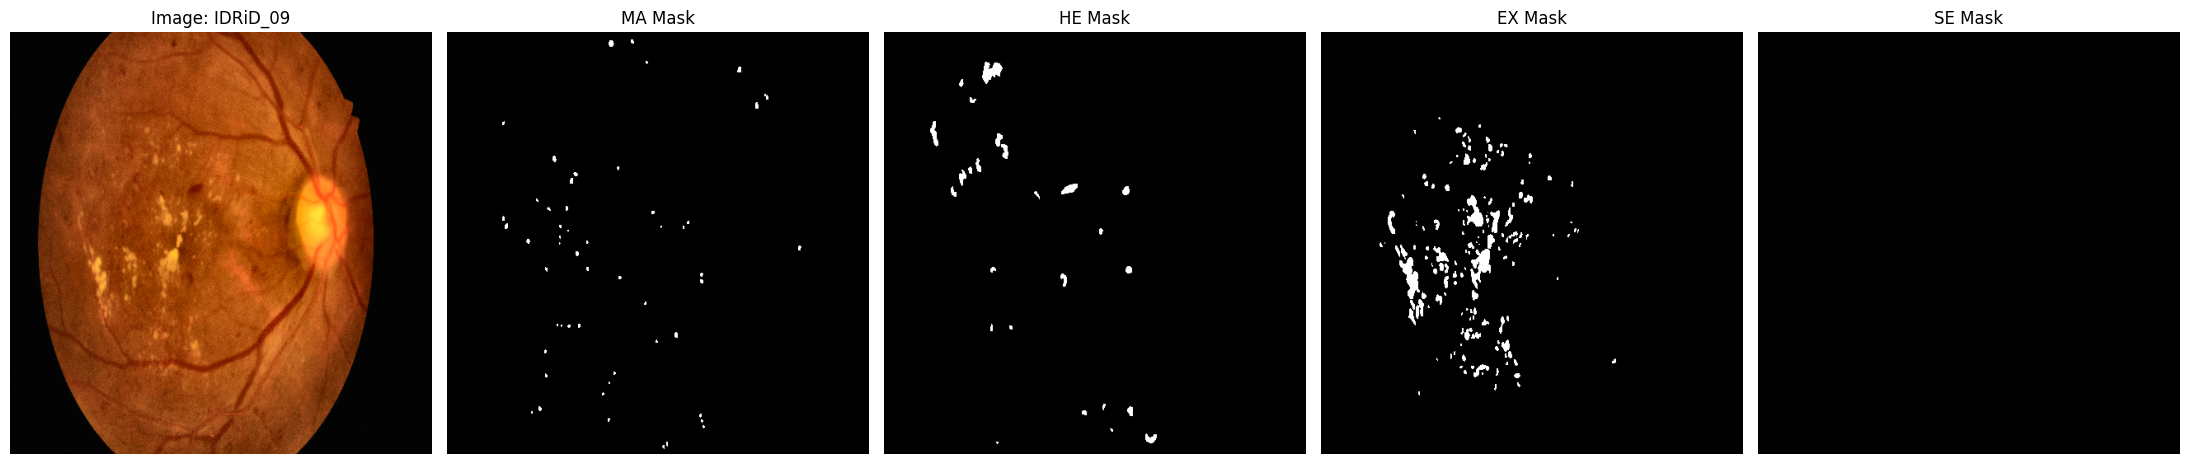

In [2]:
# =========================
# 03_dataloader.ipynb
# IDRiD DataLoader Verification
# =========================

import glob
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader


# =========================
# 1. Define dataset paths
# =========================
# These paths use the already verified IDRiD dataset structure from notebook 01.

BASE = Path("/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation")

IMG_TRAIN_DIR = BASE / "1. Original Images" / "a. Training Set"

GT_TRAIN_DIR = BASE / "2. All Segmentation Groundtruths" / "a. Training Set"

MASK_DIRS = {
    "MA": GT_TRAIN_DIR / "1. Microaneurysms",
    "HE": GT_TRAIN_DIR / "2. Haemorrhages",
    "EX": GT_TRAIN_DIR / "3. Hard Exudates",
    "SE": GT_TRAIN_DIR / "4. Soft Exudates",
}


# =========================
# 2. Define preprocessing constants
# =========================

TARGET_SIZE = (512, 512)  # OpenCV uses width, height

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


# =========================
# 3. Helper functions
# =========================

def list_files(folder):
    """
    Collect image files from a folder.

    The IDRiD dataset may contain .jpg, .png, or .tif files depending on
    whether the file is an original fundus image or a lesion mask.
    """
    exts = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]

    files = []
    for ext in exts:
        files.extend(glob.glob(str(folder / ext)))

    return sorted(files)


def get_image_id(path):
    """
    Extract the shared image ID from original images and mask files.

    Examples:
    IDRiD_01.jpg     -> IDRiD_01
    IDRiD_01_MA.tif  -> IDRiD_01
    IDRiD_01_HE.tif  -> IDRiD_01
    """
    stem = Path(path).stem
    parts = stem.split("_")

    if len(parts) >= 2:
        return parts[0] + "_" + parts[1]

    return stem


def make_id_map(files):
    """
    Create a dictionary mapping:

    image_id -> file_path

    This makes it easy to match each fundus image with its corresponding masks.
    """
    return {get_image_id(file): file for file in files}


def load_rgb_image(path):
    """
    Load an original fundus image as RGB.

    Output shape:
    H x W x 3
    """
    image = Image.open(path).convert("RGB")
    return np.array(image)


def load_mask(path):
    """
    Load a lesion mask as grayscale.

    Output shape:
    H x W
    """
    mask = Image.open(path).convert("L")
    return np.array(mask)


def create_zero_mask(image):
    """
    Create an all-zero mask when a lesion mask file is missing.

    The zero mask uses the same height and width as the original image.
    This means:
    - missing mask = no annotated lesion for that lesion type
    - no assertion error is raised
    """
    height, width = image.shape[:2]
    return np.zeros((height, width), dtype=np.uint8)


def resize_rgb_image(image):
    """
    Resize RGB image to 512x512.

    Bilinear interpolation is used for natural RGB images.
    """
    return cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)


def resize_mask(mask):
    """
    Resize lesion mask to 512x512.

    Nearest-neighbor interpolation is used for masks so that mask values
    are not blurred or mixed during resizing.
    """
    return cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)


def apply_clahe_rgb(image):
    """
    Apply CLAHE only to the RGB image.

    CLAHE is applied to the L channel in LAB color space.
    Masks are never passed through CLAHE.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced_l = clahe.apply(l_channel)

    enhanced_lab = cv2.merge((enhanced_l, a_channel, b_channel))
    enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

    return enhanced_rgb


def imagenet_normalize(image):
    """
    Apply ImageNet normalization only to the RGB image.

    Input image:
    H x W x 3, uint8, values 0 to 255

    Output image:
    H x W x 3, float32, normalized channel-wise
    """
    image = image.astype(np.float32) / 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD

    return image


def mask_to_binary(mask):
    """
    Convert mask to binary format.

    Any non-zero pixel becomes 1.
    This is suitable for lesion segmentation training.
    """
    binary_mask = (mask > 0).astype(np.float32)
    return binary_mask


# =========================
# 4. PyTorch Dataset class
# =========================

class IDRiDDataset(Dataset):
    """
    PyTorch Dataset for IDRiD lesion segmentation.

    For each sample, this dataset returns:
    - image tensor
    - MA mask tensor
    - HE mask tensor
    - EX mask tensor
    - SE mask tensor

    Missing lesion masks are replaced by all-zero masks.
    """

    def __init__(self, image_dir, mask_dirs):
        """
        Initialize the dataset.

        image_dir:
        folder containing original fundus images

        mask_dirs:
        dictionary containing folders for MA, HE, EX, and SE masks
        """

        self.image_dir = Path(image_dir)
        self.mask_dirs = mask_dirs

        # Build image path map
        self.image_files = list_files(self.image_dir)
        self.image_map = make_id_map(self.image_files)

        # Keep image IDs sorted for stable indexing
        self.image_ids = sorted(self.image_map.keys())

        # Build mask path maps for each lesion type
        self.mask_maps = {}

        for mask_name, mask_dir in self.mask_dirs.items():
            mask_files = list_files(mask_dir)
            self.mask_maps[mask_name] = make_id_map(mask_files)

        # Basic verification: dataset should contain images
        assert len(self.image_ids) > 0, "No images found in image directory."

    def __len__(self):
        """
        Return number of original fundus images.
        """
        return len(self.image_ids)

    def __getitem__(self, index):
        """
        Load and preprocess one sample.

        Steps:
        1. Load original RGB image.
        2. Load MA, HE, EX, SE masks.
        3. If a mask is missing, create an all-zero mask.
        4. Resize image and masks to 512x512.
        5. Apply CLAHE only to RGB image.
        6. Apply ImageNet normalization only to image.
        7. Convert image and masks to PyTorch tensors.
        """

        image_id = self.image_ids[index]
        image_path = self.image_map[image_id]

        # Load original RGB fundus image
        image = load_rgb_image(image_path)

        # Load each lesion mask, or create zero mask if missing
        masks = {}

        for mask_name in ["MA", "HE", "EX", "SE"]:
            if image_id in self.mask_maps[mask_name]:
                mask_path = self.mask_maps[mask_name][image_id]
                mask = load_mask(mask_path)
            else:
                mask = create_zero_mask(image)

            masks[mask_name] = mask

        # Resize image to 512x512
        image = resize_rgb_image(image)

        # Resize all masks to 512x512
        masks = {
            mask_name: resize_mask(mask)
            for mask_name, mask in masks.items()
        }

        # Apply CLAHE only to RGB image
        image = apply_clahe_rgb(image)

        # Apply ImageNet normalization only to RGB image
        image = imagenet_normalize(image)

        # Convert image from H x W x C to C x H x W for PyTorch
        image = np.transpose(image, (2, 0, 1))

        # Convert image to torch tensor
        image = torch.tensor(image, dtype=torch.float32)

        # Convert masks to binary tensors with shape 1 x H x W
        ma_mask = torch.tensor(mask_to_binary(masks["MA"]), dtype=torch.float32).unsqueeze(0)
        he_mask = torch.tensor(mask_to_binary(masks["HE"]), dtype=torch.float32).unsqueeze(0)
        ex_mask = torch.tensor(mask_to_binary(masks["EX"]), dtype=torch.float32).unsqueeze(0)
        se_mask = torch.tensor(mask_to_binary(masks["SE"]), dtype=torch.float32).unsqueeze(0)

        # Verification checks for one sample
        assert image.shape == (3, 512, 512), f"Wrong image tensor shape: {image.shape}"
        assert ma_mask.shape == (1, 512, 512), f"Wrong MA mask shape: {ma_mask.shape}"
        assert he_mask.shape == (1, 512, 512), f"Wrong HE mask shape: {he_mask.shape}"
        assert ex_mask.shape == (1, 512, 512), f"Wrong EX mask shape: {ex_mask.shape}"
        assert se_mask.shape == (1, 512, 512), f"Wrong SE mask shape: {se_mask.shape}"

        return {
            "image": image,
            "MA": ma_mask,
            "HE": he_mask,
            "EX": ex_mask,
            "SE": se_mask,
            "image_id": image_id,
        }


# =========================
# 5. Create train_dataset and train_loader
# =========================

train_dataset = IDRiDDataset(
    image_dir=IMG_TRAIN_DIR,
    mask_dirs=MASK_DIRS
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)


# =========================
# 6. Verify dataset and one batch
# =========================

print("Dataset length:", len(train_dataset))

batch = next(iter(train_loader))

print("\nOne batch keys:")
print(batch.keys())

print("\nOne batch shapes:")
print("Image batch shape:", batch["image"].shape)
print("MA mask batch shape:", batch["MA"].shape)
print("HE mask batch shape:", batch["HE"].shape)
print("EX mask batch shape:", batch["EX"].shape)
print("SE mask batch shape:", batch["SE"].shape)

print("\nSingle sample tensor shapes from batch:")
print("Image tensor shape:", batch["image"][0].shape)
print("MA mask tensor shape:", batch["MA"][0].shape)
print("HE mask tensor shape:", batch["HE"][0].shape)
print("EX mask tensor shape:", batch["EX"][0].shape)
print("SE mask tensor shape:", batch["SE"][0].shape)


# =========================
# 7. Extra verification checks
# =========================

assert len(train_dataset) == 54, f"Expected 54 training images, found {len(train_dataset)}"

assert batch["image"].shape == (4, 3, 512, 512), f"Wrong image batch shape: {batch['image'].shape}"
assert batch["MA"].shape == (4, 1, 512, 512), f"Wrong MA batch shape: {batch['MA'].shape}"
assert batch["HE"].shape == (4, 1, 512, 512), f"Wrong HE batch shape: {batch['HE'].shape}"
assert batch["EX"].shape == (4, 1, 512, 512), f"Wrong EX batch shape: {batch['EX'].shape}"
assert batch["SE"].shape == (4, 1, 512, 512), f"Wrong SE batch shape: {batch['SE'].shape}"

print("\nDataLoader verification passed.")


# =========================
# 8. Visualization helper
# =========================

def denormalize_image(image_tensor):
    """
    Convert normalized image tensor back to displayable RGB image.

    Input:
    image tensor with shape 3 x 512 x 512

    Output:
    image array with shape 512 x 512 x 3, values clipped to 0 to 1
    """

    image = image_tensor.detach().cpu().numpy()

    # Convert C x H x W to H x W x C
    image = np.transpose(image, (1, 2, 0))

    # Reverse ImageNet normalization
    image = (image * IMAGENET_STD) + IMAGENET_MEAN

    # Clip values for proper visualization
    image = np.clip(image, 0, 1)

    return image


def visualize_batch_sample(batch, sample_index=0):
    """
    Visualize one sample from a DataLoader batch.

    Displays:
    - preprocessed RGB image
    - MA mask
    - HE mask
    - EX mask
    - SE mask
    """

    image = denormalize_image(batch["image"][sample_index])

    ma_mask = batch["MA"][sample_index, 0].detach().cpu().numpy()
    he_mask = batch["HE"][sample_index, 0].detach().cpu().numpy()
    ex_mask = batch["EX"][sample_index, 0].detach().cpu().numpy()
    se_mask = batch["SE"][sample_index, 0].detach().cpu().numpy()

    image_id = batch["image_id"][sample_index]

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(image)
    axes[0].set_title(f"Image: {image_id}")
    axes[0].axis("off")

    axes[1].imshow(ma_mask, cmap="gray")
    axes[1].set_title("MA Mask")
    axes[1].axis("off")

    axes[2].imshow(he_mask, cmap="gray")
    axes[2].set_title("HE Mask")
    axes[2].axis("off")

    axes[3].imshow(ex_mask, cmap="gray")
    axes[3].set_title("EX Mask")
    axes[3].axis("off")

    axes[4].imshow(se_mask, cmap="gray")
    axes[4].set_title("SE Mask")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# 9. Visualize one batch sample
# =========================

visualize_batch_sample(batch, sample_index=0)